# Weak/Integral SINDy Feature Overview
It is often difficult to identify dynamical systems in the presence of substantial noise. Towards that end, a number of publications have used SINDy to identify the weak-formulation (integral formulation) of the system of ODEs or PDEs. This allows one to avoid taking high-order derivatives of noisy data (high-order derivatives of noisy data will amplify the noise). 

This notebook provides a simple overview of the weak form PDE functionality of PySINDy, following the examples in the PDE-FIND paper (Rudy, Samuel H., Steven L. Brunton, Joshua L. Proctor, and J. Nathan Kutz. "Data-driven discovery of partial differential equations." Science Advances 3, no. 4 (2017): e1602614) and Reinbold, P. A., Gurevich, D. R., & Grigoriev, R. O. (2020). Using noisy or incomplete data to discover models of spatiotemporal dynamics. Physical Review E, 101(1), 010203. Jupyter notebook written by Alan Kaptanoglu and Zachary Nicolaou.

As of release 1.7, the weak formulation is vectorized and much faster to compute. The "num_pts_per_domain" variable is now deprecated. It can still be passed to the WeakPDELibrary to avoid breaking old code, but it will raise a DeprecationWarning and do nothing to the library.

An interactive version of this notebook is available on binder
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/dynamicslab/pysindy/v1.7.3?filepath=examples/12_weakform_SINDy_examples.ipynb)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.linear_model import Lasso
from scipy.io import loadmat
from sklearn.metrics import root_mean_squared_error
from pysindy.utils.odes import lorenz

import pysindy as ps
import sindy_exp as exp
import sympy as sp
from sindy_exp._utils import unionize_coeff_dicts
# Ignore matplotlib deprecation warnings
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Seed the random number generators for reproducibility
np.random.seed(100)

# integration keywords for solve_ivp, typically needed for chaotic systems
integrator_keywords = {}
integrator_keywords["rtol"] = 1e-12
integrator_keywords["method"] = "LSODA"
integrator_keywords["atol"] = 1e-12

/home/jake/github/sindy-addl-examples/env12/lib/python3.12/site-packages/dysts/base.py:22: UserWarning: Numba not installed. Falling back to no JIT compilation.
  warnings.warn("Numba not installed. Falling back to no JIT compilation.")


# Test weak form ODE functionality on Lorenz equation

In [2]:
# Generate measurement data
dt = 0.002
t_train = np.arange(0, 10, dt)
t_train_span = (t_train[0], t_train[-1])
u0_train = [-8, 8, 27]
u_train = solve_ivp(
    lorenz, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
).y.T

# Instantiate and fit the SINDy model with u_dot
u_dot = ps.FiniteDifference()(u_train, t=dt)
model = ps.SINDy()
model.fit(u_train, x_dot=u_dot, t=dt)
model.print()

# Define weak form ODE library
# defaults to derivative_order = 0 if not specified,
# and if spatial_grid is not specified, defaults to None,
# which allows weak form ODEs.
# library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y]
# library_function_names = [lambda x: x, lambda x: x + x, lambda x, y: x + y]
function_library=ps.PolynomialLibrary(degree=2,include_bias=False)

threshold = 0.05
reg_wt = ps.SR3.calculate_l0_weight(threshold, 1)
optimizer = ps.SR3(
    reg_weight_lam=reg_wt, regularizer="l1", max_iter=1000, normalize_columns=False, tol=1e-1
)

wk_model = ps.WeakSINDy(
    optimizer=optimizer,
    feature_library=function_library,
    diff_kwargs={"is_uniform": True},)

# Instantiate and fit the SINDy model with the integral of u_dot
wk_model.fit(u_train, t_train)
wk_model.print()

(x0)' = -9.999 x0 +  9.999 x1
(x1)' =  27.992 x0 + -0.999 x1 + -1.000 x0 x2
(x2)' = -2.666 x2 +  1.000 x0 x1
(x0)' = -9.999 x0 +  9.999 x1
(x1)' =  27.999 x0 + -0.999 x1 + -0.999 x0 x2
(x2)' = -2.665 x2 +  0.999 x0 x1


Performance should improve as the number of sub-domain integrations points increases (numerically approximating the integrals better and better) and number of sub-domains increases (more points for regression). Let's use some noisy Lorenz data and investigate.

In [3]:
x0 = sp.parse_expr("x0")
x1 = sp.parse_expr("x1")
x2 = sp.parse_expr("x2")
x0x2 = sp.parse_expr("x0*x2")
x0x1 = sp.parse_expr("x0*x1")

true_eqns = [
    {x0: -10.0, x1: 10.0},
    {x0: 28.0, x1: -1.0, x0x1: -1.0},
    {x2: -8 / 3, x0x1: 1.0},
]

In [4]:
# Generate measurement data
dt = 0.001
t_train = np.arange(0, 10, dt)
t_train_span = (t_train[0], t_train[-1])
u0_train = [-8, 8, 27]
u0_test = [8, 7, 15]
u_train = solve_ivp(
    lorenz, t_train_span, u0_train, t_eval=t_train, **integrator_keywords
).y.T
u_test = solve_ivp(
    lorenz, t_train_span, u0_test, t_eval=t_train, **integrator_keywords
).y.T
rmse = root_mean_squared_error(u_train, np.zeros((u_train).shape))
u_dot_clean = ps.FiniteDifference()(u_test, t=dt)
u_clean = u_test
u_train = u_train + np.random.normal(0, rmse / 5.0, u_train.shape)  # Add 20% noise
rmse = root_mean_squared_error(u_test, np.zeros(u_test.shape))
u_test = u_test + np.random.normal(0, rmse / 5.0, u_test.shape)  # Add 20% noise
u_dot = ps.FiniteDifference()(u_test, t=dt)

# Same library terms as before
# library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y]
# library_function_names = [lambda x: x, lambda x: x + x, lambda x, y: x + y]

# Scan over the number of integration points and the number of subdomains
n = 10
errs = np.zeros((n))
K_scan = np.linspace(20, 2000, n, dtype=int)
for i, K in enumerate(K_scan):
    feat_lib = ps.PolynomialLibrary(degree=2,include_bias=True)
    threshold = 0.05
    reg_wt = ps.SR3.calculate_l0_weight(threshold, 1)
    opt = ps.SR3(
        reg_weight_lam=reg_wt, regularizer="l1", max_iter=1000, normalize_columns=False, tol=1e-1
    )

    # Instantiate and fit the SINDy model with the integral of u_dot
    model = ps.WeakSINDy(
        feature_library=feat_lib, optimizer=opt, n_subdomains=K, diff_kwargs={"is_uniform": True}
    )
    model.fit(u_train, t_train)
    true_aligned, est_aligned = unionize_coeff_dicts(model, true_eqns)
    # errs[i] = exp.coeff_metrics(est_aligned, true_aligned)["coeff_mae"]
    errs[i] = exp.pred_metrics(model, u_test, u_dot)["pred_l2_fro"]
    # errs[i] = np.sqrt(
    #     (
    #         np.sum((u_dot_train_integral - opt.Theta_ @ opt.coef_.T) ** 2)
    #         / np.sum(u_dot_train_integral**2)
    #     )
    #     / u_dot_train_integral.shape[0]
    # )

Performance clearly improves as the number of subdomains increases! We can also see that Lorenz is correctly identified despite ~20% noise levels.

The plot belows shows that we can use the weak-formulation to build models that are robust to noise, and additionally indicates convergence as the regression becomes larger and more accurate. 

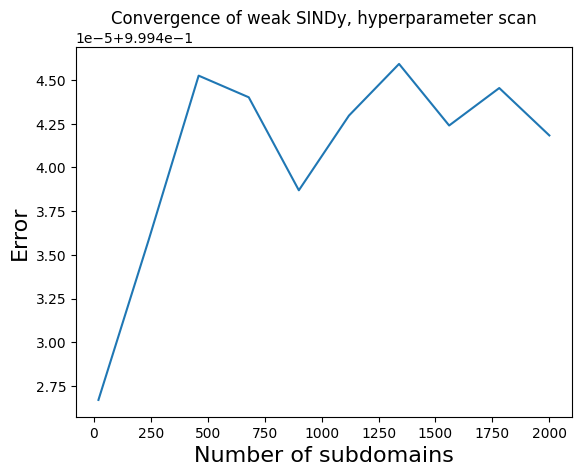

In [5]:
plt.title("Convergence of weak SINDy, hyperparameter scan", fontsize=12)
plt.plot(K_scan, errs)
plt.xlabel("Number of subdomains", fontsize=16)
plt.ylabel("Error", fontsize=16)
plt.show()

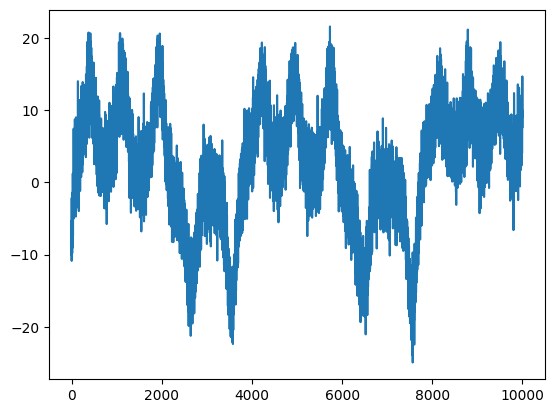

In [6]:
plt.plot(u_train[:, 0])

In [7]:
feature_names = ["x", "y", "z"]

poly_lib = ps.PolynomialLibrary(degree=2)
reg_wt = ps.SR3.calculate_l0_weight(threshold=150, relax_coeff_nu=1)
opt = ps.SR3(
    reg_weight_lam=reg_wt, regularizer="l0", max_iter=1000, normalize_columns=True, tol=1e-10,
)
# opt = ps.STLSQ()
wk_model = ps.WeakSINDy(
    optimizer=opt, feature_library=poly_lib, n_subdomains=5000, diff_kwargs={"is_uniform": True}
)
wk_model.fit(u_train, st_grids=t_train, feature_names=feature_names)
print("Weak form model: ")
wk_model.print()

# Instantiate and fit a non-weak SINDy model
optimizer = ps.SR3(
    reg_weight_lam=reg_wt, regularizer="l0", max_iter=1000, normalize_columns=True, tol=1e-10,
)
nonwk_model = ps.SINDy(feature_library=poly_lib, optimizer=optimizer)
nonwk_model.fit(u_train, t=t_train, feature_names=feature_names)
print("Regular model: ")
nonwk_model.print()
# err_not_weak = np.sqrt(
#     (np.sum((u_dot - optimizer.Theta_ @ optimizer.coef_.T) ** 2) / np.sum(u_dot**2))
#     / u_dot.shape[0]
# )

u_dot_pred = nonwk_model.predict(u_test)
u_dot_weak = wk_model.predict(u_test)

u_pred = nonwk_model.simulate(u0_test, t=t_train, integrator="odeint")
u_pred_weak = wk_model.simulate(u0_test, t=t_train, integrator="odeint")


Weak form model: 
(x)' = -9.981 x +  9.993 y
(y)' =  13.995 1 +  29.615 x + -1.444 y + -1.507 z + -0.231 x^2 +  0.251 x y + -1.042 x z + -0.076 y^2 +  0.045 z^2
(z)' = -2.442 z +  0.216 x^2 +  0.846 x y + -0.018 z^2
Regular model: 
(x)' = -52.763 1 + -7.108 x +  10.803 y +  4.585 z +  0.366 x^2 + -0.459 x y +  0.206 x z +  0.074 y^2 + -0.370 y z + -0.088 z^2
(y)' =  13.274 1 +  1.810 x +  14.251 y + -1.394 z +  0.492 x^2 + -0.119 x y + -0.053 x z + -0.099 y^2 + -0.595 y z +  0.005 z^2
(z)' = -2.461 1 + -10.144 x +  6.475 y + -4.329 z + -0.335 x^2 +  0.323 x z +  0.703 y^2 + -0.248 y z +  0.110 z^2


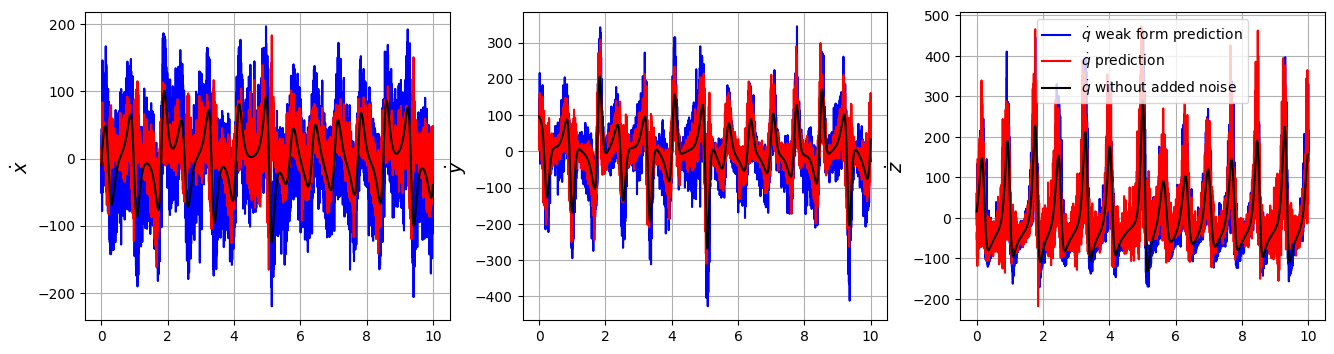

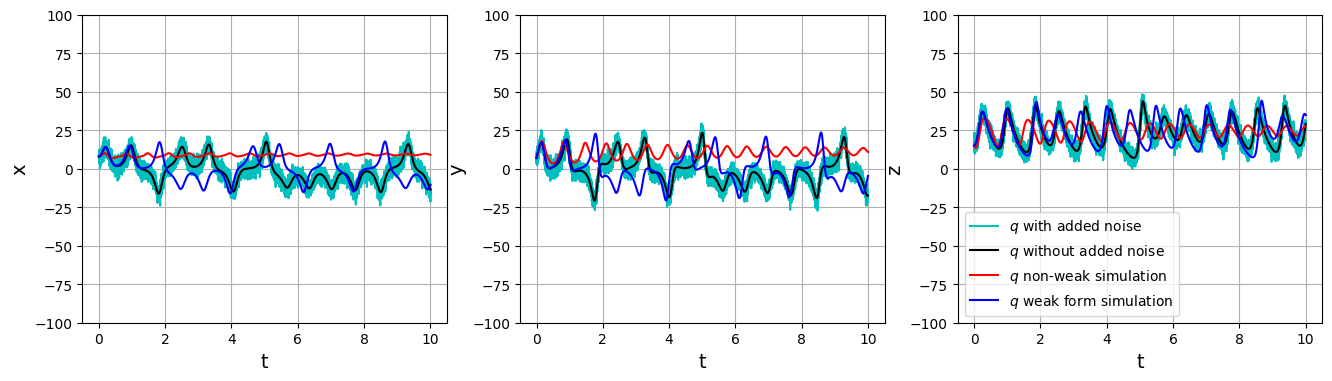

In [8]:

# Plot the ground truth, weak form, and non-weak derivative predictions
optimizer.coef_ = opt.coef_
plt.figure(figsize=(16, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(t_train, u_dot_weak[:, i], "b", label=r"$\dot{q}$ weak form prediction")
    plt.plot(t_train, u_dot_pred[:, i], "r", label=r"$\dot{q}$ prediction")
    plt.plot(t_train, u_dot_clean[:, i], "k", label=r"$\dot{q}$ without added noise")
    plt.grid(True)
    plt.ylabel(r"$\dot{" + feature_names[i] + "}$", fontsize=14)
    if i == 2:
        plt.legend()

# Plot the ground truth, weak form, and non-weak trajectory predictions
plt.figure(figsize=(16, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(t_train, u_test[:, i], "c", label=r"$q$ with added noise")
    plt.plot(t_train, u_clean[:, i], "k", label=r"$q$ without added noise")
    plt.plot(t_train, u_pred[:, i], "r", label=r"$q$ non-weak simulation")
    plt.plot(t_train, u_pred_weak[:, i], "b", label=r"$q$ weak form simulation")
    plt.grid(True)
    plt.ylabel(feature_names[i], fontsize=14)
    plt.xlabel("t", fontsize=14)
    plt.ylim(-100, 100)
    if i == 2:
        plt.legend()

# Test weak form PDE functionality on Burgers' equation with 20% noise
Note that the weak formulation can be applied to PDEs too. 
Burgers' equation is
$u_t = -uu_x + 0.1 u_{xx}$. We will repeat all the same steps. Although weak-formulation helps with noisy data, we also show that using smoothed finite-differences (or other more advanced differentiation schemes) can also improve robustness to noise.

In [9]:
# Seed the random number generators for reproducibility
np.random.seed(100)

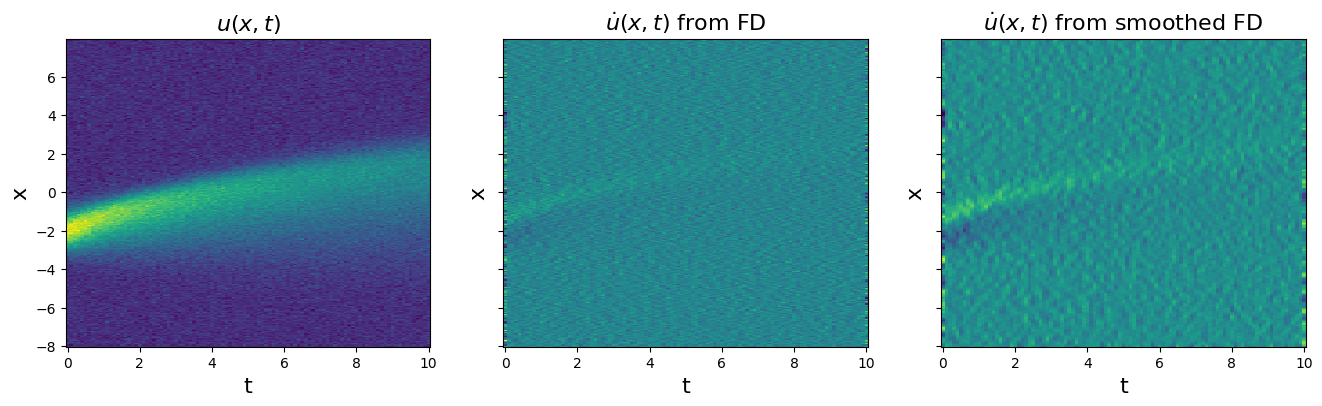

In [10]:
data = loadmat("data/burgers.mat")
time = np.ravel(data["t"])
x = np.ravel(data["x"])
u = np.real(data["usol"])
dt = time[1] - time[0]
dx = x[1] - x[0]
rmse = root_mean_squared_error(u, np.zeros(u.shape))
# add 20% noise (note the impact on derivatives depends on step size...)
u = u + np.random.normal(0, rmse / 5.0, u.shape)

# Plot u and u_dot
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.pcolormesh(time, x, u)
plt.xlabel("t", fontsize=16)
plt.ylabel("x", fontsize=16)
plt.title(r"$u(x, t)$", fontsize=16)

u_dot = ps.FiniteDifference(axis=1)(u, t=time)
plt.subplot(1, 3, 2)
plt.pcolormesh(time, x, u_dot)
plt.xlabel("t", fontsize=16)
plt.ylabel("x", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title(r"$\dot{u}(x, t)$ from FD", fontsize=16)

u_dot = ps.SmoothedFiniteDifference(axis=1)(u, t=time)
plt.subplot(1, 3, 3)
plt.pcolormesh(time, x, u_dot)
plt.xlabel("t", fontsize=16)
plt.ylabel("x", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title(r"$\dot{u}(x, t)$ from smoothed FD", fontsize=16)
plt.show()
# See how much SmoothedFiniteDifference improves the derivatives!

u = np.reshape(np.asarray(u), (len(x), len(time), 1))

In [11]:
# Define weak form PDE library
# library_functions = [lambda x: x, lambda x: x * x]
# library_function_names = [lambda x: x, lambda x: x + x]

# Need to define the 2D spatiotemporal grid before calling the library
X, T = np.meshgrid(x, time, indexing="ij")
st_grid = np.stack([X, T], axis=-1)
spatial_grid = st_grid[..., 0, :-1]

bias_lib = ps.PolynomialLibrary(0)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
pde_lib = ps.PDELibrary(2, spatial_grid = spatial_grid, diff_kwargs={"is_uniform": True})
lib = poly_lib + pde_lib + poly_lib * pde_lib

In [12]:
# Fit a weak form model
reg_wt = ps.SR3.calculate_l0_weight(.1, 1)
opt = ps.SR3(
    reg_weight_lam=reg_wt, regularizer="l0", tol=1e-8, normalize_columns=True, max_iter=1000
)
np.random.seed(1)
model = ps.WeakSINDy(
    feature_library=lib,
    optimizer=opt,
    n_subdomains=1000)
model.fit(u, st_grids=st_grid, feature_names=["u"])
model.print()

(u)' =  0.096 u_11 + -1.020 u_1 u


In [13]:
# Show that a non-weak form model screws this up badly

# Fit and predict with the non-weak model
model_for_prediction = ps.SINDy(feature_library=lib, optimizer=opt)
model_for_prediction.fit(u, time)

# Prints a very wrong model
model_for_prediction.print()

(x0)' =  0.108 x0 + -0.313 x0^2 + -0.012 x0_1 + -0.117 x0 x0_1 + -0.004 x0 x0_11 + -0.278 x0^2 x0_1 +  0.005 x0^2 x0_11


The takeaway here is that the weak formulation drastically improved our system identification on the Burgers' equation with added noise. The weak formulation can handle even more than 20% noise here, although then a fairly large value for K is required to obtain a decent system identification. This is required for some of the examples below, and the downside is that this slows down the code considerably. 

# Test weak form PDE functionality on 2d compressible isothermal flow equations with mixed function-derivative terms
Here we fit  the coupled momentum and mass transport equations in two dimensions
$$ \mathbf{u}_ t = -(\mathbf{u}\cdot\nabla)\mathbf{u} + (-\nabla P + \mu \nabla^2 \mathbf{u})/\rho,$$
$$ \rho_ t = -\nabla \cdot(\rho \mathbf{u}),$$
where we use the isothermal ideal gas law $ P = \rho R T$ as the equation of state.
Unlike the other PDE examples shown, these equations contains mixed derivative/function terms like $\rho^{-1} u_{xx}$, so this is a nice check that the full PDE functionality works,

In [14]:
def compressible(t, U, x, N, mu, RT):
    """On a square grid of N by N points"""
    u = U.reshape(N, N, 3)[:, :, 0]
    v = U.reshape(N, N, 3)[:, :, 1]
    rho = U.reshape(N, N, 3)[:, :, 2]
    ux = ps.differentiation.FiniteDifference(
        d=1,
        axis=0,
        periodic=True,
    )(u, x)
    uy = ps.differentiation.FiniteDifference(
        d=1,
        axis=1,
        periodic=True,
    )(u, x)
    uxx = ps.differentiation.FiniteDifference(
        d=2,
        axis=0,
        periodic=True,
    )(u, x)
    uyy = ps.differentiation.FiniteDifference(
        d=2,
        axis=1,
        periodic=True,
    )(u, x)
    vx = ps.differentiation.FiniteDifference(
        d=1,
        axis=0,
        periodic=True,
    )(v, x)
    vy = ps.differentiation.FiniteDifference(
        d=1,
        axis=1,
        periodic=True,
    )(v, x)
    vxx = ps.differentiation.FiniteDifference(
        d=2,
        axis=0,
        periodic=True,
    )(v, x)
    vyy = ps.differentiation.FiniteDifference(
        d=2,
        axis=1,
        periodic=True,
    )(v, x)
    px = ps.differentiation.FiniteDifference(
        d=1,
        axis=0,
        periodic=True,
    )(rho * RT, x)
    py = ps.differentiation.FiniteDifference(
        d=1,
        axis=1,
        periodic=True,
    )(rho * RT, x)
    ret = np.zeros((N, N, 3))
    ret[:, :, 0] = -(u * ux + v * uy) - (px - mu * (uxx + uyy)) / rho
    ret[:, :, 1] = -(u * vx + v * vy) - (py - mu * (vxx + vyy)) / rho
    ret[:, :, 2] = -(u * px / RT + v * py / RT + rho * ux + rho * vy)
    return ret.reshape(3 * N * N)


N = 64
Nt = 100
L = 5
T = 0.5
mu = 1
RT = 1

t = np.linspace(0, T, Nt)
x = np.arange(0, N) * L / N
y = np.arange(0, N) * L / N
dx = x[1] - x[0]

# some arbitrary initial conditions
y0 = np.zeros((N, N, 3))
y0[:, :, 0] = (
    -np.sin(2 * np.pi / L * x)[:, np.newaxis]
    + 0.5 * np.cos(2 * 2 * np.pi / L * y)[np.newaxis, :]
)
y0[:, :, 1] = (
    0.5 * np.cos(2 * np.pi / L * x)[:, np.newaxis]
    - np.sin(2 * 2 * np.pi / L * y)[np.newaxis, :]
)
y0[:, :, 2] = (
    1
    + 0.5
    * np.cos(2 * np.pi / L * x)[:, np.newaxis]
    * np.cos(2 * 2 * np.pi / L * y)[np.newaxis, :]
)

sol = solve_ivp(
    compressible,
    (t[0], t[-1]),
    y0=y0.reshape(3 * N * N),
    t_eval=t,
    args=(x, N, mu, RT),
    method="RK45",
    rtol=1e-8,
    atol=1e-8,
)

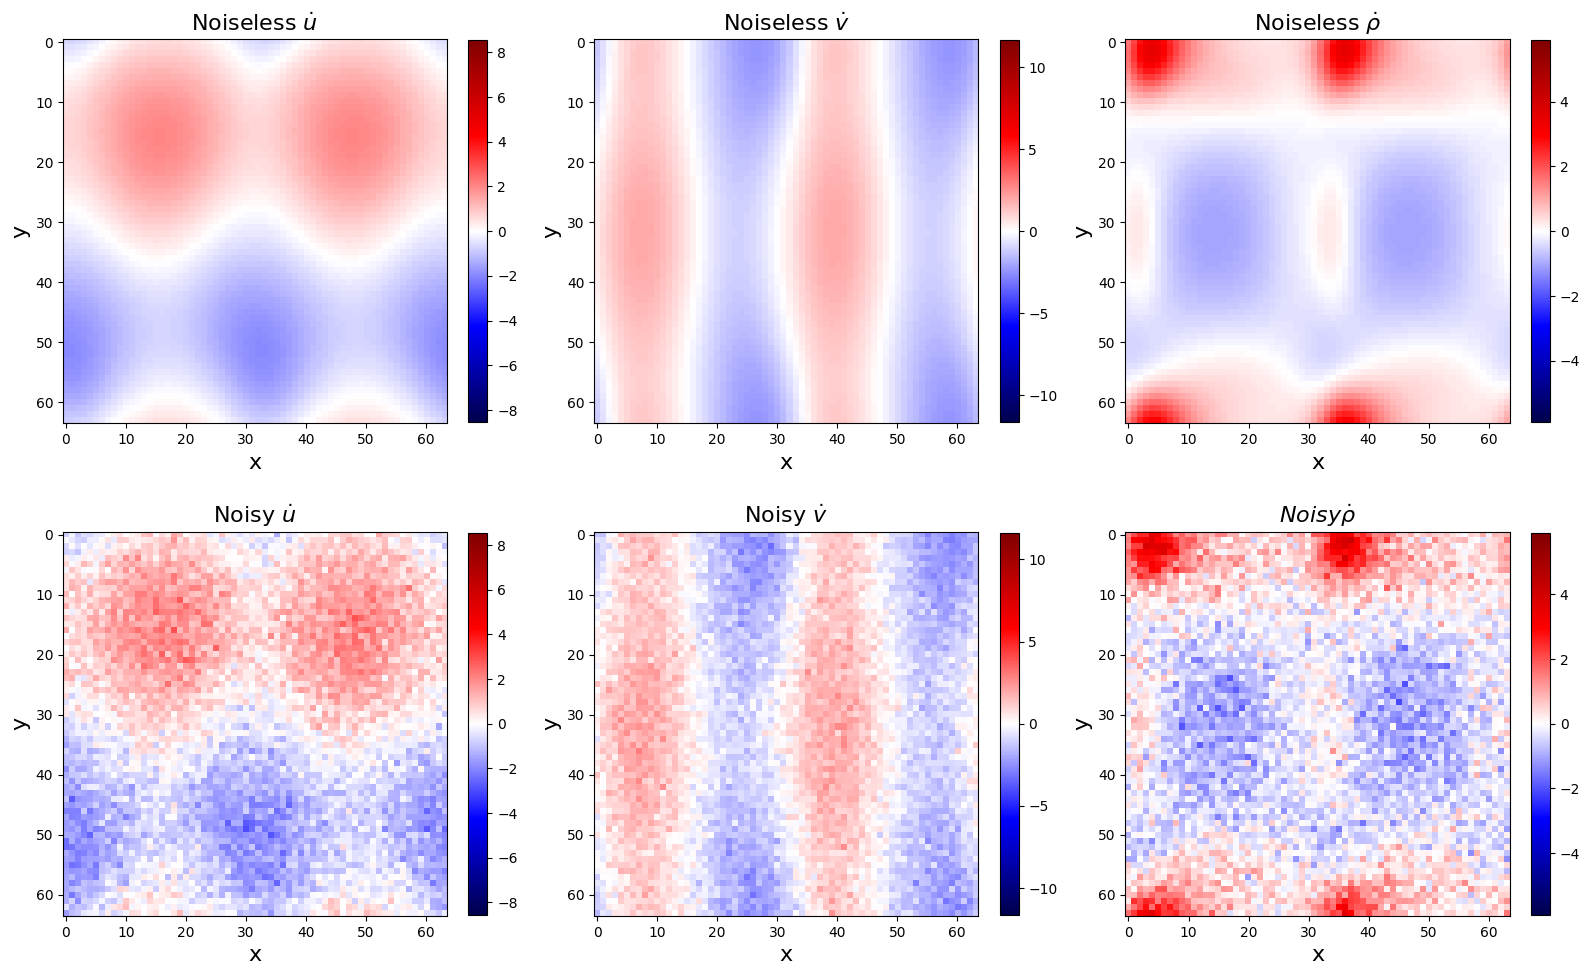

In [15]:
u_shaped_noiseless = sol.y.reshape(N, N, 3, -1).transpose(0, 1, 3, 2)
u_dot_noiseless = ps.FiniteDifference(d=1, axis=2)(u_shaped_noiseless, t)

ep = 5e-3
np.random.seed(100)
rmse = root_mean_squared_error(sol.y.flatten(), np.zeros_like(sol.y.flatten()))
u_shaped_noisy = u_shaped_noiseless + np.random.normal(0, rmse / 250.0, u_shaped_noiseless.shape)

# u_shaped_noisy = u_shaped_noiseless + 2 * ep * (
#     0.5 - np.random.random(size=(N, N, Nt, 3))
# )
u_dot_noisy = ps.FiniteDifference(d=1, axis=2)(u_shaped_noisy, t)

# Plot u and u_dot
plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(u_dot_noiseless[:, :, Nt // 2, 0], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 0])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 0])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title(r"Noiseless $\dot{u}$", fontsize=16)

plt.subplot(2, 3, 2)
plt.imshow(u_dot_noiseless[:, :, Nt // 2, 1], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 1])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 1])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title(r"Noiseless $\dot{v}$", fontsize=16)

plt.subplot(2, 3, 3)
plt.imshow(u_dot_noiseless[:, :, Nt // 2, 2], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 2])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 2])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title(r"Noiseless $\dot{\rho}$", fontsize=16)

plt.subplot(2, 3, 4)
plt.imshow(u_dot_noisy[:, :, Nt // 2, 0], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 0])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 0])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
plt.title(r"Noisy $\dot{u}$", fontsize=16)

plt.subplot(2, 3, 5)
plt.imshow(u_dot_noisy[:, :, Nt // 2, 1], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 1])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 1])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
plt.title(r"Noisy $\dot{v}$", fontsize=16)

plt.subplot(2, 3, 6)
plt.imshow(u_dot_noisy[:, :, Nt // 2, 2], cmap="seismic")
plt.clim(
    -np.max(np.abs(u_dot_noiseless[:, :, :, 2])),
    np.max(np.abs(u_dot_noiseless[:, :, :, 2])),
)
plt.colorbar(fraction=0.045)
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
plt.title(r"$Noisy \dot{\rho}$", fontsize=16)

plt.tight_layout()
plt.show()

#### Regular PDELibrary struggles with noisy data!

In [16]:
spatial_grid = np.zeros((N, N, 2))
spatial_grid[:, :, 0] = x[:, np.newaxis]
spatial_grid[:, :, 1] = y[np.newaxis, :]

library_functions = [lambda x: x, lambda x: 1 / (1e-6 + abs(x))]
library_function_names = [lambda x: x, lambda x: x + "^-1"]
clib = ps.CustomLibrary(
    library_functions=library_functions,
    function_names=library_function_names
)
pde_lib = ps.PDELibrary(
    derivative_order=2,
    spatial_grid=spatial_grid,
    diff_kwargs={"is_uniform": True, "periodic": True},
)
lib = clib + pde_lib + clib * pde_lib

# Fit the clean data (prints the correct model)
optimizer = ps.STLSQ(threshold=5e-1, alpha=1e-10, normalize_columns=False)
model = ps.SINDy(
    feature_library=lib, optimizer=optimizer
)
model.fit(u_shaped_noiseless, t=t, feature_names=["u", "v", "p"])
print("Noiseless differential fit:")
model.print()
print("R2 score: ", model.score(u_shaped_noiseless, t=t))

# Fit the noisy data (prints a bad model)
optimizer = ps.STLSQ(threshold=5e-1, alpha=1e-10, normalize_columns=False)
model = ps.SINDy(
    feature_library=lib, optimizer=optimizer
)
model.fit(u_shaped_noisy, t=t, feature_names=["u", "v", "p"])
print("Noisy differential fit:")
model.print()
print("R2 score (noisy data): ", model.score(u_shaped_noisy, t=t))
print("R2 score (noiseless data): ", model.score(u_shaped_noiseless, t=t))

Noiseless differential fit:
(u)' = -1.000 u u_1 + -1.001 v u_2 +  1.000 p^-1 u_22 + -1.000 p^-1 p_1 +  1.000 p^-1 u_11
(v)' = -1.000 u v_1 + -1.001 v v_2 + -1.000 p^-1 p_2 +  1.000 p^-1 v_22 +  1.000 p^-1 v_11
(p)' = -1.000 u p_1 + -1.000 v p_2 + -1.000 p v_2 + -1.000 p u_1
R2 score:  0.9999987554807594
Noisy differential fit:
(u)' = -1.971 u + -0.595 u u_1 + -0.901 v u_2 +  0.839 p^-1 v_2
(v)' = -1.611 v + -0.836 v v_2 + -4.081 p^-1 u_2
(p)' = -0.992 u p_1 + -0.998 v p_2 + -0.999 p v_2 + -0.998 p u_1
R2 score (noisy data):  0.8708708223262729
R2 score (noiseless data):  0.968688207974116


#### WeakPDELibrary works great for noisy data!

In [17]:
spatiotemporal_grid = np.zeros((N, N, Nt, 3))
spatiotemporal_grid[:, :, :, 0] = x[:, np.newaxis, np.newaxis]
spatiotemporal_grid[:, :, :, 1] = y[np.newaxis, :, np.newaxis]
spatiotemporal_grid[:, :, :, 2] = t[np.newaxis, np.newaxis, :]


# Fit the clean data
optimizer = ps.STLSQ(threshold=5e-1, alpha=1e-12, normalize_columns=False)
subdomain_dims = np.array([L / 10, L / 10, T / 10])
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=2000)
model.fit(u_shaped_noiseless, st_grids=spatiotemporal_grid, feature_names=["u", "v", "p"], H_xt=subdomain_dims)
print("Noiseless weak fit:")
model.print()
print("R2 score: ", model.score(u_shaped_noiseless, t=t))

# Fit the noisy data
optimizer = ps.STLSQ(threshold=5e-1, alpha=1e-12, normalize_columns=False)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=2000)
model.fit(u_shaped_noisy, st_grids=spatiotemporal_grid, feature_names=["u", "v", "p"], H_xt=subdomain_dims)
print("Noisy weak fit:")
model.print()
print("R2 score (noisy data): ", model.score(u_shaped_noisy, t=t))
print("R2 score (noiseless data): ", model.score(u_shaped_noiseless, t=t))

Noiseless weak fit:
(u)' = -0.995 u_2 v +  1.004 u_22 p^-1 + -0.997 u_1 u + -1.000 p_1 p^-1 +  1.001 u_11 p^-1
(v)' = -1.002 v_2 v + -1.003 p_2 p^-1 +  1.002 v_22 p^-1 + -0.999 v_1 u +  1.000 v_11 p^-1
(p)' = -1.000 v_2 p + -1.000 p_2 v + -1.000 u_1 p + -1.000 p_1 u
R2 score:  0.9999945575026539
Noisy weak fit:
(u)' = -0.998 u_2 v +  1.004 u_22 p^-1 + -0.996 u_1 u + -0.999 p_1 p^-1 +  1.000 u_11 p^-1
(v)' = -0.999 v_2 v + -1.002 p_2 p^-1 +  1.001 v_22 p^-1 + -0.999 v_1 u +  1.000 v_11 p^-1
(p)' = -0.999 v_2 p + -1.000 p_2 v + -1.000 u_1 p + -1.000 p_1 u
R2 score (noisy data):  -0.46553172885083166
R2 score (noiseless data):  0.9999947911839943


The R2 score here reflects how well the model's dynamics fits the model's smoothed trajectory.
Because none of these models include any smoothing, the R2 score on noisy data demonstrates that the traditional PDEFIND approach learns more of the noise,
whereas the weak formulation learns a much truer model of the underlying dynamics.

# Test weak-formulation PDE functionality on the Kuramoto-Sivashinsky equation
The Kuramoto-Sivashinsky equation is
$u_t = -uu_x - u_{xx} - u_{xxxx}$. We will skip noisy data for now, since we have already illustrated the pitfalls and performance with the weak form. We will revisit noisy data for the 2D reaction-diffusion example.

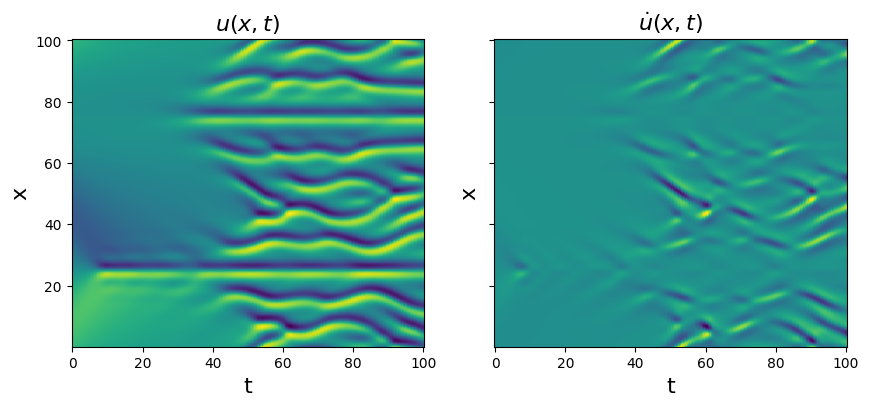

In [18]:
# Load and plot the data
data = loadmat("data/kuramoto_sivishinky.mat")
time = np.ravel(data["tt"])
x = np.ravel(data["x"])
u = data["uu"]
dt = time[1] - time[0]
dx = x[1] - x[0]

# Plot u and u_dot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.pcolormesh(time, x, u)
plt.xlabel("t", fontsize=16)
plt.ylabel("x", fontsize=16)
plt.title(r"$u(x, t)$", fontsize=16)

u_dot = ps.FiniteDifference(axis=1)(u, t=time)
plt.subplot(1, 2, 2)
plt.pcolormesh(time, x, u_dot)
plt.xlabel("t", fontsize=16)
plt.ylabel("x", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title(r"$\dot{u}(x, t)$", fontsize=16)
plt.show()

u = u.reshape(len(x), len(time), 1)

In [19]:
# Define weak form PDE library
X, T = np.meshgrid(x, time, indexing="ij")
XT = np.stack([X, T], axis=-1)
poly_lib = ps.PolynomialLibrary(degree=2, include_bias=False)
pde_lib = ps.PDELibrary(
    derivative_order=4,
    spatial_grid=x[:, None],
    diff_kwargs={"is_uniform": True, "periodic": True}
)
lib = poly_lib + pde_lib + poly_lib * pde_lib

In [20]:
# Run optimizers
optimizer = ps.STLSQ(threshold=0.4, alpha=0.05, normalize_columns=True)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

threshold = 0.8
reg_wt = ps.SR3.calculate_l0_weight(threshold, 1)
optimizer = ps.SR3(
    reg_weight_lam=reg_wt, max_iter=1000, regularizer="l0", normalize_columns=True
)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

optimizer = ps.SR3(
    reg_weight_lam=0.02, max_iter=1000, regularizer="l1", normalize_columns=True
)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

optimizer = ps.SSR(normalize_columns=True, kappa=1e-20, max_iter=20)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

optimizer = ps.SSR(
    criteria="model_residual", normalize_columns=True, kappa=1e-20, max_iter=20
)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

optimizer = ps.FROLS(normalize_columns=True, kappa=1e-20)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=200)
model.fit(u, XT, feature_names=["u"])
model.print()

(u)' = -1.000 u_11 + -1.000 u_1111 + -1.000 u_1 u +  0.002 u_111 u
(u)' = -0.998 u_11 + -0.999 u_1111 + -1.002 u_1 u
(u)' = -0.984 u_11 + -0.983 u_1111 + -0.993 u_1 u
(u)' = -0.999 u_11 + -1.000 u_1111 + -1.002 u_1 u
(u)' = -0.999 u_11 + -1.000 u_1111 + -1.002 u_1 u
(u)' = -1.000 u_11 + -1.000 u_1111 + -1.000 u_1 u +  0.002 u_111 u


**Okay, so all the optimizers essentially capture the model but often have some much smaller "extra" terms.**
The best way to deal with these spurious terms is to use ensembling, i.e. the generation of many models by sub-sampling the data, or sub-sampling the SINDy candidate library. See notebook 13 for many examples of how to use these methods. 

You can also deal with this by scanning over the hyperparameters for each method although this is more laborious for the user. 

**Next we try the SR3 optimizer on the same data but with added noise of varying levels to illustrate the robustness to noisy data.**
Ideally, we would cross-validate over 10-20 noise instantiations, but with this high-dimensional data this can be computationally slow. We compute the coefficient model errors defined through
$$\Delta\xi_{u_{xx}} = \|\xi_{u_{xx}}^{true} - \xi_{u_{xx}}^{pred}\| / \|\xi_{u_{xx}}^{true}\| =  \|-1 - \xi_{u_{xx}}^{pred}\|,$$
and similarly for the other coefficients.

In [21]:
# Get average SR3 performance as function of the noise level.
cross_val_runs = 1
u = np.squeeze(u)
rmse = root_mean_squared_error(u, np.zeros(u.shape))
noise_levels = np.linspace(0, rmse / 2.0, 5)
delta_c1 = np.zeros((cross_val_runs, len(noise_levels)))
delta_c2 = np.zeros((cross_val_runs, len(noise_levels)))
delta_c3 = np.zeros((cross_val_runs, len(noise_levels)))

# Make a weak form library with high-resolution
# Pick an optimizer with some plausible hyperparameters
optimizer = ps.SR3(reg_weight_lam=reg_wt, max_iter=1000, regularizer="l0", normalize_columns=True)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=400)
# Loop over noisy data and cross-validate
for i in range(cross_val_runs):
    for j, noise in enumerate(noise_levels):
        u_noisy = u + np.random.normal(0, noise, u.shape)
        u_noisy = np.reshape(u_noisy, (len(x), len(time), 1))
        model.fit(u_noisy, XT, feature_names=["u"])
        model.print()
        c1 = abs(optimizer.coef_[0, 6])
        c2 = abs(optimizer.coef_[0, 3])
        c3 = abs(optimizer.coef_[0, 5])
        delta_c1[i, j] = abs(abs(c1 - 1.0) / c1)
        delta_c2[i, j] = abs(abs(c2 - 1.0) / c2)
        delta_c3[i, j] = abs(abs(c3 - 1.0) / c3)

(u)' = -0.998 u_11 + -0.999 u_1111 + -1.002 u_1 u
(u)' = -0.993 u_11 + -0.995 u_1111 + -0.998 u_1 u
(u)' = -0.995 u_11 + -0.996 u_1111 + -0.995 u_1 u + -0.001 u_11 u
(u)' =  0.020 u + -0.010 u_1 + -0.973 u_11 + -0.973 u_1111 + -0.986 u_1 u +  0.001 u_11 u +  0.001 u_11 u^2
(u)' = -0.007 u + -0.990 u_11 + -0.991 u_1111 + -0.978 u_1 u


Now that we have computed the error in the model coefficients at each noise level, we plot the results.
We show below that the weak form nicely works for even 50% Gaussian noise added to every point, showing the power of the weak-formulation for robust system identification.

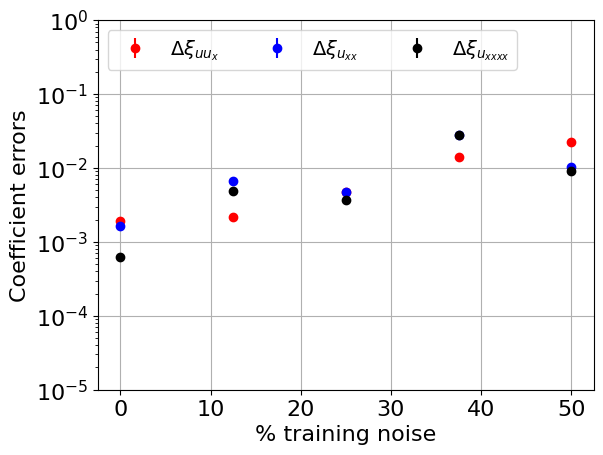

In [22]:
# Find mean and std over the validation runs
delta_c1_mean = np.nanmean(delta_c1, axis=0)
delta_c2_mean = np.nanmean(delta_c2, axis=0)
delta_c3_mean = np.nanmean(delta_c3, axis=0)

delta_c1_std = np.nanstd(delta_c1, axis=0)
delta_c2_std = np.nanstd(delta_c2, axis=0)
delta_c3_std = np.nanstd(delta_c3, axis=0)

# Plot average and standard deviations of the coefficient errors
plt.figure()
plt.errorbar(
    noise_levels / rmse * 100,
    y=delta_c1_mean,
    yerr=delta_c1_std,
    color="r",
    fmt="o",
    label=r"$\Delta\xi_{uu_x}$",
)
plt.errorbar(
    noise_levels / rmse * 100,
    y=delta_c2_mean,
    yerr=delta_c2_std,
    color="b",
    fmt="o",
    label=r"$\Delta\xi_{u_{xx}}$",
)
plt.errorbar(
    noise_levels / rmse * 100,
    y=delta_c3_mean,
    yerr=delta_c3_std,
    color="k",
    fmt="o",
    label=r"$\Delta\xi_{u_{xxxx}}$",
)
plt.yscale("log")
plt.legend(fontsize=14, loc="upper left", ncol=3)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
ax = plt.gca()
ax.set_ylim(1e-5, 1)
plt.xlabel("% training noise", fontsize=16)
plt.ylabel("Coefficient errors", fontsize=16)
plt.savefig("SR3_weakformPDE_KS.png")

# Test weak form PDE functionality on Reaction-Diffusion system
We now demonstrate another more advanced example - using the weak formulation of SINDy to robustly identify a 2D PDE.
This 2D system is significantly more complicated. The reaction-diffusion system exhibits spiral waves on a periodic domain,and the PDEs are:
$$u_t = 0.1\nabla^2 u + (1-A^2)u +\beta A^2v$$
$$v_t = 0.1\nabla^2 v - \beta A^2 u + (1-A^2)v$$
$$A^2 = u^2 + v^2.$$
The main change will be a significantly larger library... cubic terms in (u, v) and all their first and second order derivatives. We will also need to generate the data because saving a high-resolution form of the data makes a fairly large file. See the Example 10 Jupyter notebook for the non-weak-form system identification of the reaction-diffusion system.

Note that the Rudy PDE-FIND paper and Messenger Weak SINDy paper use 256 spatial points in each spatial direction, but Reinbold weak SINDy PRE paper uses 512 points in each direction. We will try and get away with only 64 points in each direction for speed (with normal PDE-FIND this would be a liability because the high order derivatives are very noisy), and still show robustness to ~ 10% noise levels

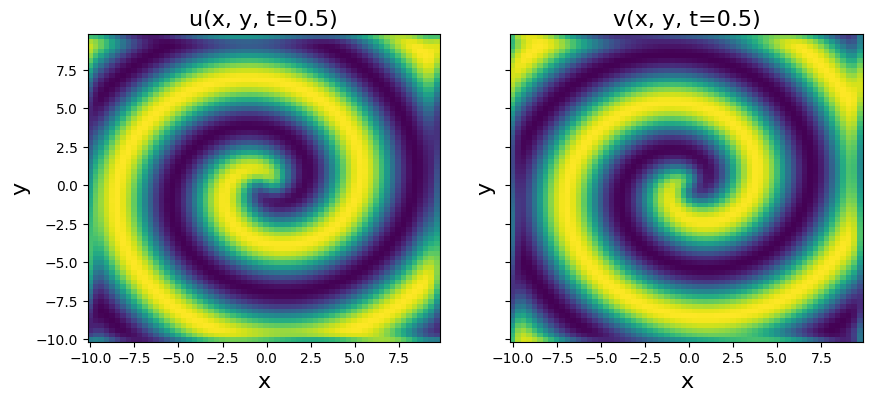

In [23]:
from numpy.fft import fft2, ifft2


# Define the reaction-diffusion PDE in the Fourier (kx, ky) space
def reaction_diffusion(t, uvt, K22, d1, d2, beta, n, N):
    ut = np.reshape(uvt[:N], (n, n))
    vt = np.reshape(uvt[N : 2 * N], (n, n))
    u = np.real(ifft2(ut))
    v = np.real(ifft2(vt))
    u3 = u**3
    v3 = v**3
    u2v = (u**2) * v
    uv2 = u * (v**2)
    utrhs = np.reshape((fft2(u - u3 - uv2 + beta * u2v + beta * v3)), (N, 1))
    vtrhs = np.reshape((fft2(v - u2v - v3 - beta * u3 - beta * uv2)), (N, 1))
    uvt_reshaped = np.reshape(uvt, (len(uvt), 1))
    uvt_updated = np.squeeze(
        np.vstack(
            (-d1 * K22 * uvt_reshaped[:N] + utrhs, -d2 * K22 * uvt_reshaped[N:] + vtrhs)
        )
    )
    return uvt_updated


# Generate the data
t = np.linspace(0, 10, int(10 / 0.1))
d1 = 0.1
d2 = 0.1
beta = 1.0
L = 20  # Domain size in X and Y directions
n = 64  # Number of spatial points in each direction
N = n * n
x_uniform = np.linspace(-L / 2, L / 2, n + 1)
x = x_uniform[:n]
y = x_uniform[:n]
n2 = int(n / 2)
# Define Fourier wavevectors (kx, ky)
kx = (2 * np.pi / L) * np.hstack((np.linspace(0, n2 - 1, n2), np.linspace(-n2, -1, n2)))
ky = kx
# Get 2D meshes in (x, y) and (kx, ky)
X, Y = np.meshgrid(x, y)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K22 = np.reshape(K2, (N, 1))

m = 1  # number of spirals

# define our solution vectors
u = np.zeros((len(x), len(y), len(t)))
v = np.zeros((len(x), len(y), len(t)))

# Initial conditions
u[:, :, 0] = np.tanh(np.sqrt(X**2 + Y**2)) * np.cos(
    m * np.angle(X + 1j * Y) - (np.sqrt(X**2 + Y**2))
)
v[:, :, 0] = np.tanh(np.sqrt(X**2 + Y**2)) * np.sin(
    m * np.angle(X + 1j * Y) - (np.sqrt(X**2 + Y**2))
)

# uvt is the solution vector in Fourier space, so below
# we are initializing the 2D FFT of the initial condition, uvt0
uvt0 = np.squeeze(
    np.hstack(
        (np.reshape(fft2(u[:, :, 0]), (1, N)), np.reshape(fft2(v[:, :, 0]), (1, N)))
    )
)

# Solve the PDE in the Fourier space, where it reduces to system of ODEs
uvsol = solve_ivp(
    reaction_diffusion, (t[0], t[-1]), y0=uvt0, t_eval=t, args=(K22, d1, d2, beta, n, N)
)
uvsol = uvsol.y

# Reshape things and ifft back into (x, y, t) space from (kx, ky, t) space
for j in range(len(t)):
    ut = np.reshape(uvsol[:N, j], (n, n))
    vt = np.reshape(uvsol[N:, j], (n, n))
    u[:, :, j] = np.real(ifft2(ut))
    v[:, :, j] = np.real(ifft2(vt))

# Plot to check if spiral is nicely reproduced
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.pcolor(X, Y, u[:, :, 10])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title("u(x, y, t=0.5)", fontsize=16)
plt.subplot(1, 2, 2)
plt.pcolor(X, Y, v[:, :, 10])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title("v(x, y, t=0.5)", fontsize=16)

dt = t[1] - t[0]
dx = x[1] - x[0]
dy = y[1] - y[0]

u_sol = u
v_sol = v

In [24]:
u = np.zeros((n, n, len(t), 2))
u[:, :, :, 0] = u_sol
u[:, :, :, 1] = v_sol

# Odd polynomial terms in (u, v), up to second order derivatives in (u, v)
library_functions = [
    lambda x: x,
    lambda x: x * x * x,
    lambda x, y: x * y * y,
    lambda x, y: x * x * y,
]
library_function_names = [
    lambda x: x,
    lambda x: x + x + x,
    lambda x, y: x + y + y,
    lambda x, y: x + x + y,
]
odd_lib = ps.CustomLibrary(library_functions, library_function_names)

np.random.seed(100)
# Need to define the 2D spatial grid before calling the library
X, Y, T = np.meshgrid(x, y, t, indexing="ij")
XYT = np.stack([X, Y, T], axis=-1)

pde_lib = ps.PDELibrary(
    derivative_order=2,
    spatial_grid=XYT[..., 0, :2],
    diff_kwargs={"is_uniform": True, "periodic": True},
)
lib = odd_lib + pde_lib


In [25]:
# Fit the 2D reaction-diffusion equation, weak form style!
optimizer = ps.STLSQ(threshold=0.05, alpha=1e-8, normalize_columns=True)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer)
model.fit(u, XYT, feature_names=["u", "v"])
model.print()

(u)' =  1.000 u + -1.000 uuu +  1.000 vvv + -1.000 uvv +  1.000 uuv +  0.100 u_22 +  0.100 u_11
(v)' =  1.000 v + -1.000 uuu + -1.000 vvv + -1.000 uvv + -1.000 uuv +  0.100 v_22 +  0.100 v_11


Okay, so we have captured the terms in the clean data case... can we repeat with some added noise?

In [26]:
# Need to increase the weak form mesh resolution a bit if data is noisy
np.random.seed(1)
# Allow even polynomial terms to show they get zeroed out
lib = poly_lib + pde_lib

# Initialize noisy data
rmse = root_mean_squared_error(u.flatten(), np.zeros(u.size))
u_noisy = u + np.random.normal(0, rmse / 20.0, u.shape)  # Add 5% noise

# Fit the 2D reaction-diffusion equation with noise, weak form style!
reg_wt = ps.SR3.calculate_l0_weight(0.05, 1)
optimizer = ps.STLSQ(threshold=0.05, alpha=1e-8, normalize_columns=True, unbias=True)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=2000)
model.fit(u_noisy, XYT, feature_names=["u", "v"])
model.print()

(u)' =  0.023 u +  0.908 v +  0.025 u_22 +  0.023 u_11
(v)' = -0.907 u +  0.020 v +  0.020 v_22 +  0.022 v_11


Text(0.5, 1.0, 'v(x, y, t=0.5)')

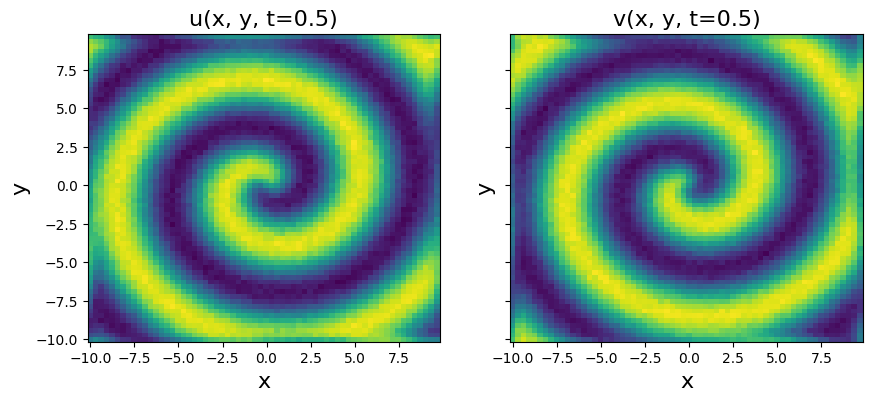

In [27]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.pcolor(*np.meshgrid(x, y), u_noisy[:, :, 10, 0])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title("u(x, y, t=0.5)", fontsize=16)
plt.subplot(1, 2, 2)
plt.pcolor(*np.meshgrid(x, y), u_noisy[:, :, 10, 1])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title("v(x, y, t=0.5)", fontsize=16)


The weak formulation works adequately with noise, but requires a relatively large K.

# Test weak form PDE functionality on 3D Reaction-Diffusion system
Can even use weak-form for 3D PDEs although this is getting computationally intensive! 

We will use a 3D reaction-diffusion equation called the Gray-Scott Equation. We are folllowing the example in Section 3.3.3 of Maddu, S., Cheeseman, B. L., Sbalzarini, I. F., & Müller, C. L. (2019). Stability selection enables robust learning of partial differential equations from limited noisy data. arXiv preprint arXiv:1907.07810. ([Link](https://arxiv.org/pdf/1907.07810.pdf)).
$$u_t = D_u\nabla^2 u - uv^2 + 0.014(1-u)$$
$$v_t = D_v\nabla^2 v + uv^2 - 0.067 v$$
We will need to generate some low-resolution data, because the memory requirements are very significant for a fully 3D problem. We can still get a pretty good model.

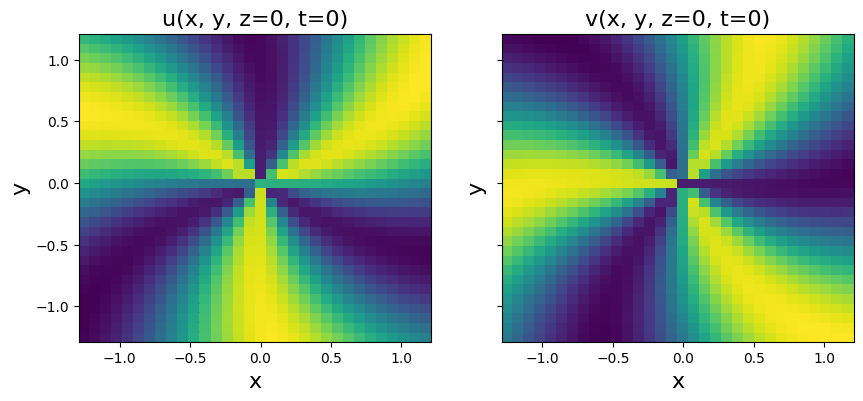

In [28]:
from numpy.fft import fftn, ifftn


# Define the reaction-diffusion PDE in the Fourier (kx, ky, kz) space
def reaction_diffusion(t, uvt, K22, d1, d2, n, N):
    ut = np.reshape(uvt[:N], (n, n, n))
    vt = np.reshape(uvt[N : 2 * N], (n, n, n))
    u = np.real(ifftn(ut, axes=[0, 1, 2]))
    v = np.real(ifftn(vt, axes=[0, 1, 2]))
    uv2 = u * (v**2)
    utrhs = np.reshape((fftn(0.014 * (1 - u) - uv2, axes=[0, 1, 2])), (N, 1))
    vtrhs = np.reshape((fftn(uv2 - 0.067 * v, axes=[0, 1, 2])), (N, 1))
    uvt_reshaped = np.reshape(uvt, (len(uvt), 1))
    uvt_updated = np.squeeze(
        np.vstack(
            (-d1 * K22 * uvt_reshaped[:N] + utrhs, -d2 * K22 * uvt_reshaped[N:] + vtrhs)
        )
    )
    return uvt_updated


# Generate the data
dt = 0.1
t = np.linspace(0, 10, int(10 / dt))
d1 = 2e-2
d2 = 1e-2
L = 2.5  # Domain size in X, Y, Z directions
n = 32  # Number of spatial points in each direction
N = n * n * n
x_uniform = np.linspace(-L / 2, L / 2, n + 1)
x = x_uniform[:n]
y = x_uniform[:n]
z = x_uniform[:n]
n2 = int(n / 2)
# Define Fourier wavevectors (kx, ky, kz)
kx = (2 * np.pi / L) * np.hstack((np.linspace(0, n2 - 1, n2), np.linspace(-n2, -1, n2)))
ky = kx
kz = kx
# Get 3D meshes in (x, y, z) and (kx, ky, kz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
K2 = KX**2 + KY**2 + KZ**2
K22 = np.reshape(K2, (N, 1))

m = 3  # number of spirals

# define our solution vectors
u = np.zeros((n, n, n, len(t)))
v = np.zeros((n, n, n, len(t)))

# Initial conditions
u[:, :, :, 0] = np.tanh(np.sqrt(X**2 + Y**2 + Z**2)) * np.cos(
    m * np.angle(X + 1j * Y) - (np.sqrt(X**2 + Y**2 + Z**2))
)
v[:, :, :, 0] = np.tanh(np.sqrt(X**2 + Y**2 + Z**2)) * np.sin(
    m * np.angle(X + 1j * Y) - (np.sqrt(X**2 + Y**2 + Z**2))
)

# uvt is the solution vector in Fourier space, so below
# we are initializing the 2D FFT of the initial condition, uvt0
uvt0 = np.squeeze(
    np.hstack(
        (
            np.reshape(fftn(u[:, :, :, 0], axes=[0, 1, 2]), (1, N)),
            np.reshape(fftn(v[:, :, :, 0], axes=[0, 1, 2]), (1, N)),
        )
    )
)

# Solve the PDE in the Fourier space, where it reduces to system of ODEs
uvsol = solve_ivp(
    reaction_diffusion, (t[0], t[-1]), y0=uvt0, t_eval=t, args=(K22, d1, d2, n, N)
)
uvsol = uvsol.y

# Reshape things and ifft back into (x, y, z, t) space from (kx, ky, kz, t) space
for j in range(len(t)):
    ut = np.reshape(uvsol[:N, j], (n, n, n))
    vt = np.reshape(uvsol[N:, j], (n, n, n))
    u[:, :, :, j] = np.real(ifftn(ut, axes=[0, 1, 2]))
    v[:, :, :, j] = np.real(ifftn(vt, axes=[0, 1, 2]))

# Plot to check if spiral is nicely reproduced
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.pcolor(X[:, :, 0], Y[:, :, 0], u[:, :, 0, 0])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
plt.title("u(x, y, z=0, t=0)", fontsize=16)
plt.subplot(1, 2, 2)
plt.pcolor(X[:, :, 0], Y[:, :, 0], v[:, :, 0, 0])
plt.xlabel("x", fontsize=16)
plt.ylabel("y", fontsize=16)
ax = plt.gca()
ax.set_yticklabels([])
plt.title("v(x, y, z=0, t=0)", fontsize=16)

dt = t[1] - t[0]
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

u_sol = u
v_sol = v

In [29]:
time = t
u = np.zeros((n, n, n, len(time), 2))
u[:, :, :, :, 0] = u_sol
u[:, :, :, :, 1] = v_sol
u_dot = ps.FiniteDifference(axis=3)(u, t)


# Need to define the 3D spatial grid before calling the library
X, Y, Z, T = np.meshgrid(x, y, z, time, indexing="ij")
spatiotemporal_grid = np.stack([X, Y, Z, T], axis=-1)
poly_lib = ps.PolynomialLibrary(degree=3)
pde_lib = ps.PDELibrary(
    derivative_order=2,
    spatial_grid=spatiotemporal_grid[..., 0, :3],
    diff_kwargs={"is_uniform": True, "periodic": True},
)
lib = poly_lib + pde_lib


In [30]:
# Fit the 3D reaction-diffusion equation
reg_wt = ps.SR3.calculate_l0_weight(1e-5, 1)
optimizer = ps.SR3(reg_weight_lam=reg_wt, max_iter=50, regularizer="l0", normalize_columns=True, unbias=True)
model = ps.WeakSINDy(feature_library=lib, optimizer=optimizer, n_subdomains=2000)
model.fit(u, spatiotemporal_grid, feature_names=["u", "v"])
model.print()

(u)' =  0.014 1 + -0.017 u + -0.999 u v^2 +  0.017 u_33 +  0.017 u_22 +  0.017 u_11
(v)' = -0.071 v +  0.986 u v^2 +  0.008 v_33 +  0.008 v_22 +  0.008 v_11


Correct equations are:
$$u_t = 0.02\nabla^2 u - uv^2 + 0.014(1-u)$$
$$v_t = 0.01\nabla^2 v + uv^2 - 0.067 v$$
So our model is pretty good!